# 최종 오버샘플링(파라미터 조정 필요)

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

# 데이터 로드
data_path = '/content/drive/MyDrive/newfile.csv'
Machine_fail = pd.read_csv(data_path)

# 데이터 자료형에 따른 column 구분
y_column = ['Machine failure']
numeric_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference']

# na값 제거
Machine_fail_cleaned = Machine_fail.dropna()

# 카테고리형 변수 인코딩
Machine_fail_encoded = pd.get_dummies(Machine_fail_cleaned[y_column], drop_first=True)

Machine_fail_combined = pd.concat([Machine_fail_encoded, Machine_fail_cleaned[numeric_columns]], axis=1)

# 추출할 특징
y_column = ['Machine failure']
ext_ordinal_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference']

# 추출된 특징만을 포함할 데이터
ext_Machine_fail_combined = Machine_fail_combined[y_column + ext_ordinal_columns]

# 학습 및 평가 데이터 분리
X = ext_Machine_fail_combined.drop(y_column, axis=1)
y = ext_Machine_fail_combined[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Mounted at /content/drive


In [2]:
from imblearn.over_sampling import SMOTE

# SMOTE를 이용한 오버샘플링
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 오버샘플링 후 클래스 별 데이터 수 확인
print("Resampled minority class count:", len(y_train_resampled[y_train_resampled == 1]))
print("Resampled majority class count:", len(y_train_resampled[y_train_resampled == 0]))

Resampled minority class count: 214866
Resampled majority class count: 214866


In [3]:
import tensorflow as tf

# GPU 사용 설정
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print('GPU 설정이 완료되었습니다.')
else:
    print('GPU를 찾을 수 없습니다. 코드가 CPU에서 실행됩니다.')

GPU 설정이 완료되었습니다.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# SVC 모델 생성
svm = SVC()

# 탐색할 파라미터 그리드 생성
param_grid = {
    'C': [0.1, 1, 10],
}

# 그리드 탐색을 위한 객체 생성
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=3, scoring='accuracy')

# 그리드 탐색 수행
grid_search.fit(X_train_resampled, y_train_resampled)

# 최적의 파라미터 출력
print("Best parameters:", grid_search.best_params_)

In [10]:
from sklearn.svm import SVC

# 클래스에 대한 사용자 정의 가중치 설정
class_weights = {0: 1, 1: 10}
svm = SVC(kernel='rbf', C=0.1, class_weight=class_weights)

In [ ]:
svm.fit(X_train_resampled, y_train_resampled)

In [12]:
# 예측 수행
y_train_pred_svm = svm.predict(X_train_resampled)
y_test_pred_svm = svm.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 평가 지표 계산: 정확도 (맞은수/전체)
acc_train = accuracy_score(y_train_resampled, y_train_pred_svm)
acc_test = accuracy_score(y_test, y_test_pred_svm)

print(f'학습 데이터를 이용한 SVM Acc 값 : {acc_train*100:.1f}%')
print(f'평가 데이터를 이용한 SVM Acc 값 : {acc_test*100:.1f}%')

# 평가 지표 계산: 정밀도, 재현율, F1 점수
precision_test = precision_score(y_test, y_test_pred_svm)
recall_test = recall_score(y_test, y_test_pred_svm)
f1_test = f1_score(y_test, y_test_pred_svm)

print(f'SVM의 Precision : {precision_test:.2f}')
print(f'SVM의 Recall : {recall_test:.2f}')
print(f'SVM의 F1 score : {f1_test:.2f}')

학습 데이터를 이용한 SVM Acc 값 : 50.0%
평가 데이터를 이용한 SVM Acc 값 : 1.6%
SVM의 Precision : 0.02
SVM의 Recall : 1.00
SVM의 F1 score : 0.03


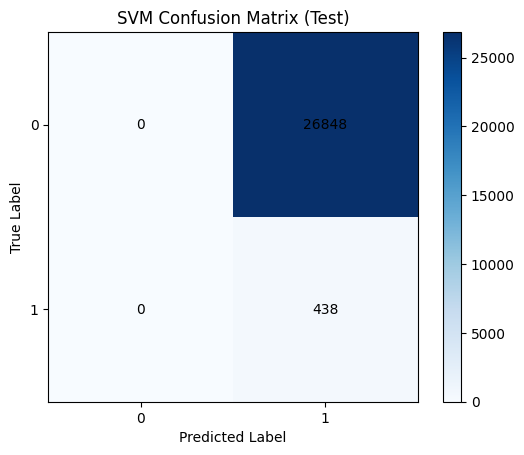

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# confusion matrix을 활용한 평가 결과 확인
cm_test_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.imshow(cm_test_svm, interpolation='nearest', cmap='Blues')
plt.title("SVM Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test_svm.shape[0]):
    for j in range(cm_test_svm.shape[1]):
        plt.text(j, i, cm_test_svm[i, j], ha="center", va="center", color="black")

svm = SVC(kernel='rbf', C=10, class_weight=class_weights)

학습 데이터를 이용한 SVM Acc 값 : 50.0%

평가 데이터를 이용한 SVM Acc 값 : 1.6%

SVM의 Precision : 0.02

SVM의 Recall : 1.00

SVM의 F1 score : 0.03



# 최종 언더샘플링 (파라미터 조정 필요)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

# 데이터 로드
data_path = '/content/drive/MyDrive/newfile.csv'
Machine_fail = pd.read_csv(data_path)

# 데이터 자료형에 따른 column 구분
y_column = ['Machine failure']
numeric_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference']

# na값 제거
Machine_fail_cleaned = Machine_fail.dropna()

# 카테고리형 변수 인코딩
Machine_fail_encoded = pd.get_dummies(Machine_fail_cleaned[y_column], drop_first=True)

Machine_fail_combined = pd.concat([Machine_fail_encoded, Machine_fail_cleaned[numeric_columns]], axis=1)

# 추출할 특징
y_column = ['Machine failure']
ext_ordinal_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference']

# 추출된 특징만을 포함할 데이터
ext_Machine_fail_combined = Machine_fail_combined[y_column + ext_ordinal_columns]

# 학습 및 평가 데이터 분리
X = ext_Machine_fail_combined.drop(y_column, axis=1)
y = ext_Machine_fail_combined[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# 언더샘플링을 위한 객체 생성
undersampler = RandomUnderSampler(random_state=42)

# 언더샘플링 수행
X_train_resampled_under, y_train_resampled_under = undersampler.fit_resample(X_train, y_train)

# 언더샘플링 후 클래스 별 데이터 수 확인
print("Resampled minority class count:", len(y_train_resampled_under[y_train_resampled_under == 1]))
print("Resampled majority class count:", len(y_train_resampled_under[y_train_resampled_under == 0]))

In [ ]:
from sklearn.svm import SVC

# 클래스에 대한 사용자 정의 가중치 설정
class_weights = {0: 1, 1: 10}
svm = SVC(kernel='rbf', C=10, class_weight=class_weights)

In [ ]:
svm.fit(X_train_resampled_under, y_train_resampled_under)

In [ ]:
# 예측 수행
y_train_pred_svm = svm.predict(X_train_resampled_under)
y_test_pred_svm = svm.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

# 평가 지표 계산: 정확도 (맞은수/전체)
acc_train = accuracy_score(y_train_resampled_under, y_train_pred_svm)
acc_test = accuracy_score(y_test, y_test_pred_svm)

print(f'학습 데이터를 이용한 SVM Acc 값 : {acc_train*100:.1f}%')
print(f'평가 데이터를 이용한 SVM Acc 값 : {acc_test*100:.1f}%')

# 평가 지표 계산: 정밀도, 재현율, F1 점수
precision_test = precision_score(y_test, y_test_pred_svm)
recall_test = recall_score(y_test, y_test_pred_svm)
f1_test = f1_score(y_test, y_test_pred_svm)

print(f'SVM의 Precision : {precision_test:.2f}')
print(f'SVM의 Recall : {recall_test:.2f}')
print(f'SVM의 F1 score : {f1_test:.2f}')

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# confusion matrix을 활용한 평가 결과 확인
cm_test_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.imshow(cm_test_svm, interpolation='nearest', cmap='Blues')
plt.title("SVM Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test_svm.shape[0]):
    for j in range(cm_test_svm.shape[1]):
        plt.text(j, i, cm_test_svm[i, j], ha="center", va="center", color="black")

# 시각화 관련

In [ ]:
# SVM 모델 학습 (선형 커널 사용)
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

# 특성 가중치 추출
feature_weights = svm_linear.coef_[0]

# 특성 가중치 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_weights)), feature_weights, color='skyblue')
plt.xticks(range(len(feature_weights)), X_train.columns, rotation=90)
plt.xlabel('Features')
plt.ylabel('Coefficient Magnitude')
plt.title('Feature Importance (Linear SVM)')
plt.show()

In [ ]:
# 특성 중요도 상위 k개의 특성 선택
k = 5
top_features_idx = np.abs(feature_weights).argsort()[-k:]

# 상위 k개의 특성 값 추출
top_features_values = X_train.iloc[:, top_features_idx]

# 각 특성 값에 대해 Machine failure의 성공/실패에 따른 분포 시각화
plt.figure(figsize=(12, 8))
for i, feature_idx in enumerate(top_features_idx):
    plt.subplot(2, 3, i + 1)
    plt.hist([top_features_values[y_train_resampled == 0].iloc[:, i],
              top_features_values[y_train_resampled == 1].iloc[:, i]],
             bins=30, color=['skyblue', 'salmon'], alpha=0.7, label=['No Failure', 'Failure'])
    plt.xlabel(X_train.columns[feature_idx])
    plt.ylabel('Frequency')
    plt.legend()
plt.tight_layout()
plt.show()